In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp.grad_scaler import GradScaler
from torch.amp.autocast_mode import autocast
from torchvision import models
from transformers import MobileNetV2Config, MobileNetV2Model
from tqdm import tqdm
import os
import sys

2026-03-28 15:58:57.900041: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-28 15:58:58.190469: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774693738.312348 1101531 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774693738.344935 1101531 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774693738.586318 1101531 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:

sys.path.append("/mnt/Personal/Projects/Autofocus/Code/Universal")

import pytorch_start # type: ignore
pytorch_start.activate_gpu(print_details=True)


                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |          3.69 | Unknown      | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+

Configured GPU 0: _CudaDeviceProperties(name='NVIDIA GeForce RTX 3050 Laptop GPU', major=8, minor=6, total_memory=3778MB, multi_processor_count=16, uuid=1fb0444c-042f-2836-2dde-93bbe9dca9b5, L2_cache_size=1MB)


In [3]:
dataset_type = "Train"
dataset_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Dataset/"+dataset_type
model_path = "/mnt/Velocity_Vault/Datasets/Autofocus/Model/"

label_path = dataset_path+"/label.mm"
patch_path = dataset_path+"/patch.mm"

meta_data_path = dataset_path+"/meta.txt"

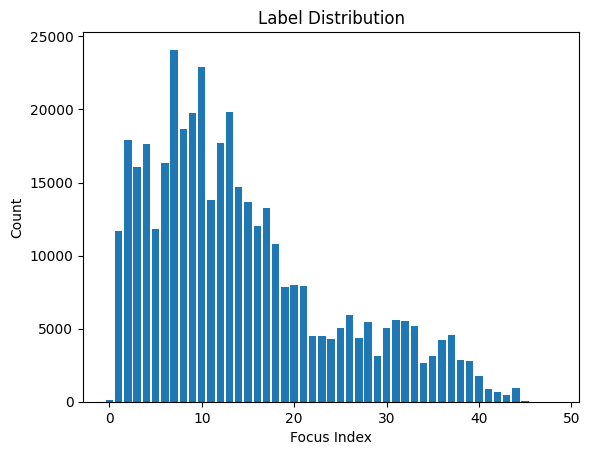

In [4]:
with open(meta_data_path, "r") as f:
    meta_data = json.load(f)
        
labels = np.memmap(label_path, dtype=np.uint8, mode='r')

hist = np.bincount(labels, minlength=49)

# print(hist)

plt.bar(range(49), hist)
plt.title("Label Distribution")
plt.xlabel("Focus Index")
plt.ylabel("Count")
plt.show()

In [5]:
def split_indices(n, val_ratio=0.1):
    indices = np.arange(n)
    np.random.shuffle(indices)

    split = int(n * (1 - val_ratio))

    train_idx = indices[:split]
    val_idx = indices[split:]

    return train_idx, val_idx

# -----------------------------
# 1. Dataset (Optimized Memmap)
# -----------------------------
class FocalStackDataset(Dataset):
    def __init__(self, patches_path, labels_path, shape, indices=None, label_offset=0):
        
        self.patches = np.memmap(patches_path, dtype=np.uint8, mode='r', shape=shape)
        self.labels = np.memmap(labels_path, dtype=np.uint8, mode='r', shape=(shape[0],))

        self.indices = indices if indices is not None else np.arange(shape[0])
        self.label_offset = label_offset

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]

        x = torch.from_numpy(self.patches[real_idx])
        y = int(self.labels[real_idx]) - self.label_offset  

        return x, torch.tensor(y, dtype=torch.long)


In [6]:


class FocusNet(nn.Module):
    def __init__(self):
        super().__init__()

        config = MobileNetV2Config(
            num_channels=49,
            image_size=32,
            depth_multiplier=0.5,
            output_stride=8,
            finegrained_output=True
        )

        self.backbone = MobileNetV2Model(config)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Linear(1280, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 40)
        )

    def forward(self, x):
        # x: (B,40,32,32)

        outputs = self.backbone(x)
        feat = outputs.last_hidden_state   # (B, C, H, W)

        feat = self.pool(feat).flatten(1)

        out = self.head(feat)

        return out

In [7]:

# # -----------------------------
# # 3. Ordinal Loss
# # -----------------------------

# def autofocus_loss(outputs, target):
#     """
#     outputs: (B, 49)
#     target: (B,)
#     """

#     class_range = torch.arange(outputs.shape[1], device=outputs.device).float()

#     prob = torch.softmax(outputs, dim=1)

#     pred = (prob * class_range).sum(dim=1)  # expected focus

#     loss = torch.nn.functional.l1_loss(pred, target.float())

#     return loss, pred



In [8]:
# Global cache
K_GLOBAL = None
CLASS_RANGE_GLOBAL = None
CACHED_SIGMA = None
CACHED_NUM_CLASSES = None

def precompute_autofocus(num_classes, sigma, device):
    global K_GLOBAL, CLASS_RANGE_GLOBAL
    global CACHED_SIGMA, CACHED_NUM_CLASSES

    # Skip if already computed with same config
    if (
        K_GLOBAL is not None and
        CLASS_RANGE_GLOBAL is not None and
        CACHED_SIGMA == sigma and
        CACHED_NUM_CLASSES == num_classes 
    ):
        return

    # ---- class range ----
    class_range = torch.arange(num_classes, device=device).float()

    # ---- distance matrix ----
    D = torch.abs(
        class_range.unsqueeze(0) - class_range.unsqueeze(1)
    )  # (C, C)

    # ---- kernel ----
    K = torch.exp(-D / sigma)
    K = K / K.sum(dim=1, keepdim=True)

    # ---- store globally ----
    K_GLOBAL = K
    CLASS_RANGE_GLOBAL = class_range

    CACHED_SIGMA = sigma
    CACHED_NUM_CLASSES = num_classes

def autofocus_loss(outputs, target, sigma=1.5):
    global K_GLOBAL, CLASS_RANGE_GLOBAL

    device = outputs.device
    num_classes = outputs.shape[1]

    # ---- ensure precomputation ----
    if (
        K_GLOBAL is None or
        CLASS_RANGE_GLOBAL is None or
        K_GLOBAL.device != device or
        K_GLOBAL.shape[0] != num_classes
    ):
        precompute_autofocus(num_classes, sigma, device)

    # ---- predicted distribution (log-space) ----
    log_prob = torch.log_softmax(outputs, dim=1)
    prob = log_prob.exp()   # recover probabilities

    # ---- soft labels via lookup ----
    soft_labels = K_GLOBAL[target.long()]   # type: ignore # (B, C)

    # ---- loss ----
    loss = -(soft_labels * log_prob).sum(dim=1).mean()

    # ---- expectation ----
    pred = (prob * CLASS_RANGE_GLOBAL).sum(dim=1) # type: ignore

    return loss, pred

In [ ]:


def train_epoch(model, loader, optimizer, scaler, device, acc_k, class_weights):
    model.train()

    total_loss = 0.0
    total_mae = 0.0
    total_acck = 0.0

    class_range = torch.arange(40, device=device).float()

    pbar = tqdm(
        loader,
        desc="Training",
        leave=False,
        dynamic_ncols=True,
        smoothing=0.1
    )

    for i, (x, y) in enumerate(pbar, 1):

        x = x.to(device, non_blocking=True).float().div(127.5).sub(1.0)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type="cuda"):
            outputs = model(x)

            prob = torch.softmax(outputs, dim=1)
            pred_cont = (prob * class_range).sum(dim=1)

            # -------------------------
            # Weighted L1 loss
            # -------------------------
            
            l1 = (pred_cont - y.float()).abs()
            weights = class_weights[y]          # (B,)
            loss = (l1 * weights).mean()
            
            # -------------------------
            # Plain L1 loss
            # -------------------------
            
            # loss = (pred_cont - y.float()).abs().mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        # ---- metrics (UNWEIGHTED, important) ----
        total_loss += loss.item()

        pred = pred_cont.round().long()

        mae = (pred_cont - y).abs().mean()   # keep raw MAE for reporting
        total_mae += mae.item()

        acck_val = ((pred - y).abs() <= acc_k).float().mean()
        total_acck += acck_val.item()

        # ---- running averages ----
        avg_loss = total_loss / i
        avg_mae = total_mae / i
        avg_acck = total_acck / i

        pbar.set_postfix_str(
            f"loss={avg_loss:.3f} | mae={avg_mae:.3f} | acc@{acc_k}={avg_acck:.3f}"
        )

    return avg_loss, avg_mae, avg_acck
    

In [ ]:

# -----------------------------
# 1. Device
# -----------------------------
def get_device():
    return torch.device("cuda")

# -----------------------------
# 4. Sampler + DataLoader
# -----------------------------
# def create_dataloader(dataset, labels_np, weights, batch_size):
def create_dataloader(dataset, batch_size):
    
    # sample_weights = weights[labels_np]

    # sampler = WeightedRandomSampler(
    #     weights=sample_weights.tolist(),
    #     num_samples=len(sample_weights),
    #     replacement=True
    # )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        pin_memory_device="cuda",
        persistent_workers=True,
        prefetch_factor=1
    )

    return loader



In [11]:


# -----------------------------
# 5. Model + Optimizer + AMP
# -----------------------------
def setup_training(device,lr):
    model = FocusNet().to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr ,betas=(0.5, 0.999))

    scaler = GradScaler()

    return model, optimizer, scaler


# -----------------------------
# 6. Scheduler
# -----------------------------
def create_scheduler(optimizer, epochs):
    return torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss
    }, path)
    
@torch.no_grad()
def validate(model, loader, device, acc_k):
    model.eval()

    total_mae = 0.0
    total_acck = 0.0

    class_range = torch.arange(40, device=device).float()

    for x, y in loader:
        x = x.to(device, non_blocking=True).float().div_(127.5).sub_(1.0)
        y = y.to(device, non_blocking=True)

        outputs = model(x)

        prob = torch.softmax(outputs, dim=1)
        pred_cont = (prob * class_range).sum(dim=1)

        pred = pred_cont.round().long()

        mae = (pred_cont - y).abs().mean()
        acck = ((pred - y).abs() <= acc_k).float().mean()

        total_mae += mae.item()
        total_acck += acck.item()

    avg_mae = total_mae / len(loader)
    avg_acck = total_acck / len(loader)

    return avg_mae, avg_acck

In [ ]:



def run_training(
    model,
    train_loader,
    val_loader,
    optimizer,
    scaler,
    scheduler,
    device,
    epochs,
    class_weights,
    acc_k,
    save_dir,
    save_every_k=5,
    patience=10,
    min_delta=1e-3
):
    os.makedirs(save_dir, exist_ok=True)

    best_val_mae = float("inf")
    patience_counter = 0

    for epoch in range(epochs):

        # ---- Train ----
        train_loss, train_mae, train_acck = train_epoch(
            model,
            train_loader,
            optimizer,
            scaler,
            device,
            acc_k,
            class_weights
        )

        # ---- Validate ----
        val_mae, val_acck = validate(
            model,
            val_loader,
            device,
            acc_k
        )

        scheduler.step()

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train → Loss: {train_loss:.4f}, MAE: {train_mae:.4f}, Acc@{acc_k}: {train_acck:.4f} | "
            f"Val → MAE: {val_mae:.4f}, Acc@{acc_k}: {val_acck:.4f}"
        )

        # ---- Save periodic checkpoint ----
        if (epoch + 1) % save_every_k == 0:
            save_path = os.path.join(save_dir, f"checkpoint_epoch_{epoch+1}.pth")
            save_checkpoint(model, optimizer, epoch+1, train_loss, save_path)

        # ---- Early stopping logic ----
        if val_mae < best_val_mae - min_delta:
            best_val_mae = val_mae
            patience_counter = 0

            # Save best model
            best_path = os.path.join(save_dir, "best_model.pth")
            torch.save(model.state_dict(), best_path)

        else:
            patience_counter += 1
            print(f"EarlyStopping counter: {patience_counter}/{patience}")

            if patience_counter >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    # ---- Save final model ----
    final_path = os.path.join(save_dir, "final_model.pth")
    torch.save(model.state_dict(), final_path)

In [13]:

def execution(
    patches_path,
    labels_path,
    train_shape,
    EPOCHS,
    batch_size,
    lr,
    save_every_k,
    save_dir,
    acck
):

    device = get_device()

    # -------------------------
    # Load labels (memmap safe)
    # -------------------------
    labels_memmap = np.memmap(
        labels_path,
        dtype=np.uint8,
        mode='r',
        shape=(train_shape[0],)
    )

    labels_np = np.array(labels_memmap)

    # -------------------------
    # Filter valid classes (1–40)
    # -------------------------
    valid_mask = (labels_np >= 1) & (labels_np <= 40)
    valid_indices = np.where(valid_mask)[0]

    print(f"Using {len(valid_indices)} / {len(labels_np)} samples after filtering")
    
        # After valid_indices
    filtered_labels = labels_np[valid_indices] - 1  # remap 1–40 → 0–39

    hist = np.bincount(filtered_labels, minlength=40)

    weights = 1.0 / (hist + 1e-6)   # avoid division by zero
    weights = weights / weights.sum() * len(weights)

    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

    # -------------------------
    # Shuffle filtered indices
    # -------------------------
    np.random.shuffle(valid_indices)

    # -------------------------
    # Train / Val split
    # -------------------------
    split = int(0.9 * len(valid_indices))

    train_idx = valid_indices[:split]
    val_idx = valid_indices[split:]

    # -------------------------
    # Datasets
    # -------------------------
    train_dataset = FocalStackDataset(
        patches_path,
        labels_path,
        train_shape,
        indices=train_idx,
        label_offset=1   # <-- IMPORTANT
    )

    val_dataset = FocalStackDataset(
        patches_path,
        labels_path,
        train_shape,
        indices=val_idx,
        label_offset=1   # <-- IMPORTANT
    )

    # -------------------------
    # Loaders
    # -------------------------
    train_loader = create_dataloader(
        train_dataset,
        batch_size=batch_size
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        pin_memory_device="cuda",
        persistent_workers=True,
        prefetch_factor=1
    )

    # -------------------------
    # Model + Optimizer
    # -------------------------
    model, optimizer, scaler = setup_training(device, lr)

    scheduler = create_scheduler(optimizer, EPOCHS)

    # -------------------------
    # Train
    # -------------------------
    run_training(
        model,
        train_loader,
        val_loader,
        optimizer,
        scaler,
        scheduler,
        device,
        EPOCHS,
        class_weights,
        acck,
        save_dir,
        save_every_k,
    )

In [14]:
execution(  patch_path,
            label_path,
            meta_data['patches']['shape'],
            EPOCHS=200,
            batch_size=128,
            lr = 1e-3,
            save_every_k = 10,
            save_dir=model_path,
            acck=2)

Using 396870 / 400000 samples after filtering


Epoch [1/200] | Train → Loss: 2.2137, MAE: 3.5403, Acc@2: 0.5303 | Val → MAE: 4.4780, Acc@2: 0.3063


Epoch [2/200] | Train → Loss: 1.2890, MAE: 2.0490, Acc@2: 0.7080 | Val → MAE: 2.0476, Acc@2: 0.6980


Epoch [3/200] | Train → Loss: 1.1545, MAE: 1.8408, Acc@2: 0.7523 | Val → MAE: 1.9108, Acc@2: 0.7496


Epoch [4/200] | Train → Loss: 1.0597, MAE: 1.7007, Acc@2: 0.7830 | Val → MAE: 2.9221, Acc@2: 0.5764
EarlyStopping counter: 1/10


...

Epoch [57/200] | Train → Loss: 0.4568, MAE: 0.7334, Acc@2: 0.9601 | Val → MAE: 0.8973, Acc@2: 0.9341
EarlyStopping counter: 6/10


Epoch [58/200] | Train → Loss: 0.4537, MAE: 0.7293, Acc@2: 0.9603 | Val → MAE: 1.0258, Acc@2: 0.9132
EarlyStopping counter: 7/10


Epoch [59/200] | Train → Loss: 0.4511, MAE: 0.7232, Acc@2: 0.9609 | Val → MAE: 1.8573, Acc@2: 0.8171
EarlyStopping counter: 8/10


Epoch [60/200] | Train → Loss: 0.4472, MAE: 0.7170, Acc@2: 0.9614 | Val → MAE: 0.8972, Acc@2: 0.9338
EarlyStopping counter: 9/10


Epoch [61/200] | Train → Loss: 0.4458, MAE: 0.7144, Acc@2: 0.9616 | Val → MAE: 0.9777, Acc@2: 0.9198
EarlyStopping counter: 10/10

Early stopping triggered at epoch 61
